# K-Means vs DBSCAN: Choosing Parameters with the Elbow Method and the k-Distance Graph

## Abstract
This activity compares two popular unsupervised clustering algorithms, **K-Means** and **DBSCAN**, using synthetic datasets with different geometries (Gaussian blobs, two moons, and concentric circles).  
For K-Means we select the number of clusters $(k)$ using the **elbow method**, for DBSCAN we select the neighborhood radius using the **k-distance graph**, which highlights a “knee” separating dense regions from sparse/noise regions.  
The experiments show that K-Means performs well when clusters are compact and approximately spherical (blobs), but it struggles on non-convex shapes (moons/circles). DBSCAN can recover non-convex clusters and labels outliers as noise, but it is sensitive to the choice of $(\varepsilon)$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Data Creation

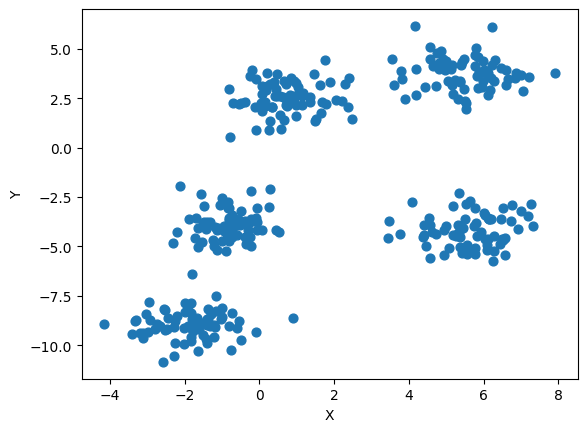

In [ ]:
# librery for make datasets
from sklearn.datasets import make_blobs
# Creating Test Data with sklearn.make_blobs
# Genrate isotropic Gaussian blobs for clustering
X, y = make_blobs(n_samples= 350, centers = 5, cluster_std=0.8, random_state=40)

def plt_data(X):
  plt.scatter(X[:, 0], X[:, 1], s = 40)
  plt.xlabel("X")
  plt.ylabel("Y")

  plt.show()

plt_data(X)

## K-Means
Kmeans is a widely used partitioning clustering algorithm. It works by assigning each data point to the nearest cluster center and then updating the centers, with the goal of creating clusters whose points are as close as possible to their centroid.
A centroid is computed as follow:
$$\mu(c) = \frac{1}{|c|} \sum_{x \in c} x$$
istances are assigned to a cluster according to the nearest centroid.

The algorithm work as follow:
1. Generate K points (seeds) in the space. These points represent the initial centroids (K randomly chosen instances);
2. Assign each instance to the cluster whose centroid is the closest according to the considered similarity/distance measure;
3. After assigning all the instances, recompute each cluster center as the mean of all the instances assigned to it;
4. Repeat steps 2 and 3 until the centroids stabilize.

K-Means tends to work best when clusters are compact, roughly spherical, and similar in size. For non-convex shapes (like spirals, moons, or crescents), its linear boundaries can’t follow the curved structure, so it often splits a single curved cluster into multiple parts.

In [ ]:
# Import Library
from sklearn.cluster import KMeans

# Apply Kmenas to the data
# We don't pass the number of cluster, he use the default 8
kmeans = KMeans(random_state=40)
kmeans.fit(X)

# Centroids
center = kmeans.cluster_centers_
labels = kmeans.labels_

In [ ]:
# Function for plotting kmeans
def plot_Kmeans(X):
  plt.figure(figsize=(8, 8))
  plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40)
  plt.scatter(center[:, 0], center[:, 1], c='red', marker='*', s=150, label='Centroids')
  plt.title("KMeans Cluster")
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.show()

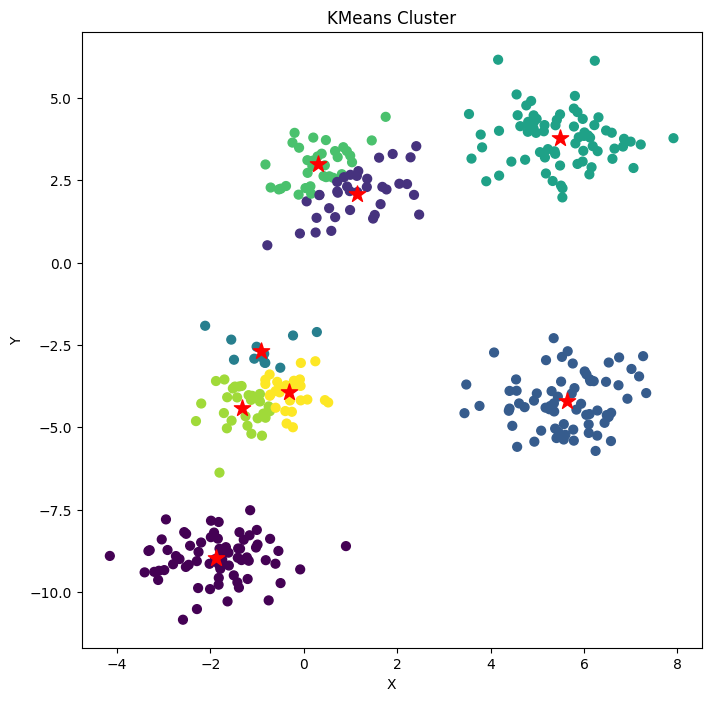

In [ ]:
plot_Kmeans(X)

## Elbow Method
We start selectiong the range of $k$ values.

For each $k$ we run K-Means and calculate WCSS (Within-Cluster Sum of Squares) which shows how close the data point are to thei cluster centroid.
$$ WCSS= \sum_{i = 1}^{k} \sum_{j = 1}^{n_i} distance(x_j^{(i)}, c_i)^2$$
where:
- $distance(x_j^{(i)}, c_i)$ represent the distance between the $j^{th}$ data point $x_j^{(i)}$ in cluster $i$ and the centroid $c_i$ of that cluster

After computig WCSS fro all $k$ we plot $k$ vs WCSS

WCSS always decreses as $k$ increses becouse more cluster reduce internal spread.

After a certain point, the improvments become very small. This elbow in the curve identicates the point where adding more clusters no longer gives meaninghful improvment.




In [ ]:
# Function for computing and plotting the elbow method
def elbow_method(X):
  wcss = []
  interias = {}
  for i in range(1,10):
    kmeans = KMeans(n_clusters = i, max_iter = 200, random_state=40)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    interias[i] = wcss[-1]

  print("Interia values:")
  for key, val in interias.items():
    print(f'{key}:{val}')

  # Plot the elbow curve
  plt.plot(range(1, 10), wcss)
  plt.title('Elbow Method')
  plt.xlabel('Number of clusters')
  plt.ylabel('WCSS')

  plt.show()

Interia values:
1:11704.362033923087
2:5048.440319422569
3:2231.667361122888
4:1385.0552895604237
5:446.0566635460663
6:416.7408727264247
7:382.71186601337723
8:377.95401578947383
9:355.2297178230983


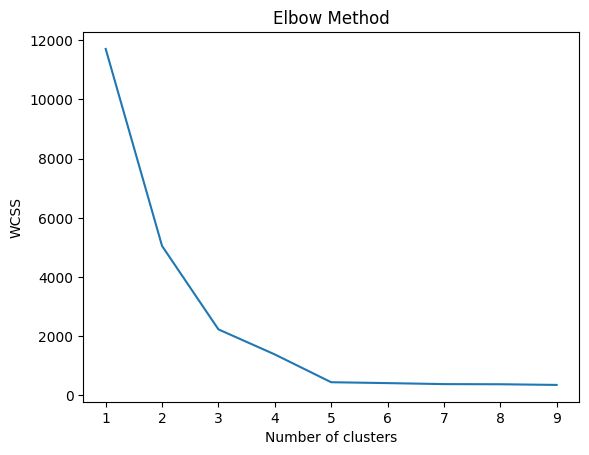

In [ ]:
elbow_method(X)

## Kmenas after elbow method

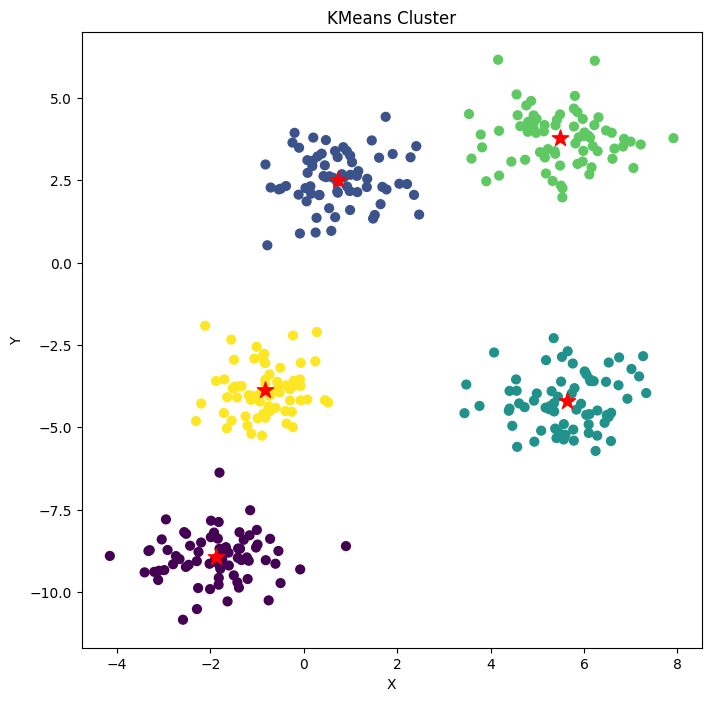

In [ ]:
# Apply kemans after wlbow method using the suggest n_cluster number
kmeans = KMeans(n_clusters = 5, init='k-means++', random_state=40)
kmeans.fit(X)

# Centroids
center = kmeans.cluster_centers_
labels = kmeans.labels_

plot_Kmeans(X)

## DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) forms clusters as dense regions in the data space and labels points in sparse regions as noise.

**Parameters**
- $\varepsilon$ (epsilon): neighborhood radius  
- $\text{minPts}$ (min_samples): minimum number of points needed to define a dense region

### Core, border, and noise points
Given a dataset $X$ and a distance function, define the $\varepsilon$-neighborhood of a point $x$ as:  
$$N_\varepsilon(x)=\{y\in X : \|y-x\|\le \varepsilon\}$$.  

- **Core point:** $x$ is a core point if $|N_\varepsilon(x)| \ge \text{minPts}$.  
- **Reachable point:** $x$ is not core, but lies within $\varepsilon$ of a core point.
- **Noise point:** $x$ is neither core nor reachable from any core point.


Starting from a core point, DBSCAN repeatedly adds all points within $\varepsilon$. A cluster is the set of points reachable through this “density expansion”. This allows DBSCAN to discover **non-convex** clusters.

This alorithm does not require specifying the number of clusters; can detect arbitrary shapes.

Is very sensitive to the selection of  $\varepsilon$ and $\text{minPts}$


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
db = DBSCAN()
db = DBSCAN(eps=0.5, min_samples=5).fit(X)
# eps: Maximum distance between two semples for one to be considered in the neighborhood of the other
# min_sanples: num of samples in an neighborhood for a point to be conisdered as a core point.


# I let eps equal to 0.5 (standard value) even if is not the better value in this
# situation for show the main different with the other methods and for show how important pick the right value is
labels_db = db.labels_


# Number of clusters
n_clusters_ = len(set(labels))

print("Estimated number of clusters: %d" % n_clusters_)

Estimated number of clusters: 5


In [ ]:
# Plot with cluster
def plot_dbscan(X):
  plt.figure(figsize=(8, 8))
  plt.scatter(X[:, 0], X[:, 1], c=labels_db, cmap='viridis', s=40)
  plt.title("DBSCAN Blob")
  plt.show()

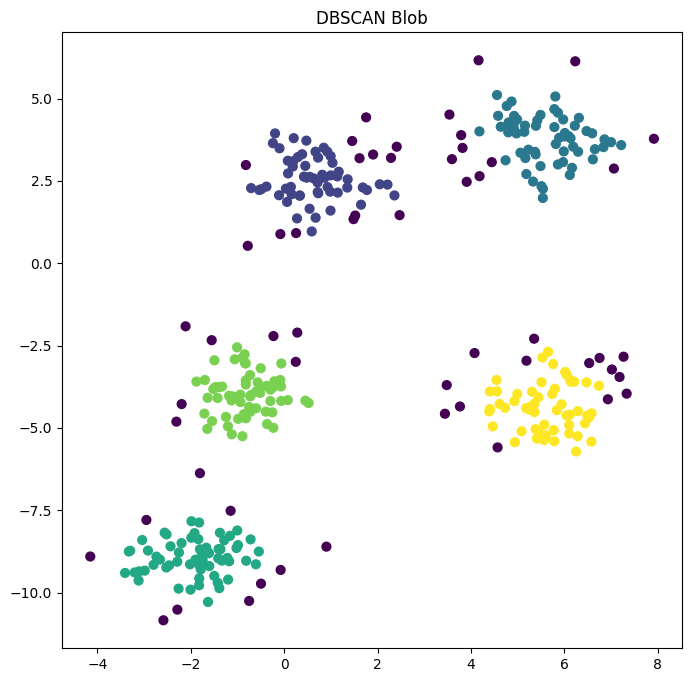

In [ ]:
plot_dbscan(X)

## K-Distance
The k-distance idea is simple: for each point, you look at how far you must go to reach its k-th nearest neighbor (where usually k = minPts).

Is important for DBSCAN becouse needs a radius $\varepsilon$ such that points inside real clusters have enough neighbors within that radius, while isolated points do not. The k-distance graph helps choose $\varepsilon$ by showing a clear change:

small k-distances → points in dense regions (clusters)

large k-distances → points in sparse regions (often noise)
Plotting all k-distances usually show an elbow and choosing $\varepsilon$ around that knee separates dense cluster points from noise.

definition of k-distance:
$$d_k(x_i)=|x_i-x_{i(k)}|$$

where $x_{i(k)}$ is the k-th nearest neighbor of $x_i$.

In [ ]:
from sklearn.neighbors import NearestNeighbors
# Function to plot k-distance graph
def k_distance(X, k = 5):
  # find k-nn for each point
  neigh = NearestNeighbors(n_neighbors=k)
  neigh.fit(X)
  # compute the distances to it's k-nn
  distances, _ = neigh.kneighbors(X)
  # Take the distanche to the k-th nearest neighbor foe each point
  distances = np.sort(distances[:, k-1])
  plt.figure(figsize=(10, 6))
  plt.plot(distances)
  plt.xlabel('Points')
  plt.ylabel(f'{k}-th nearest neighbor distance')
  plt.title('K-distance Graph')
  plt.show()


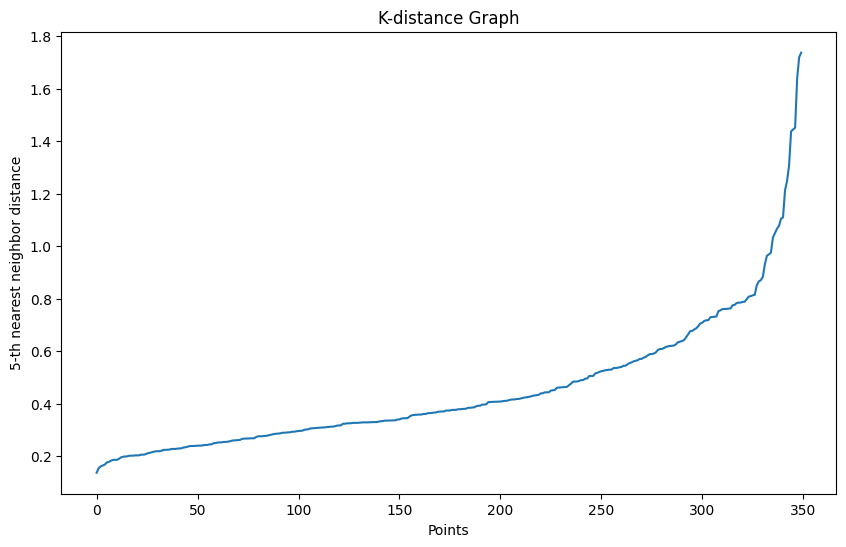

In [ ]:
k_distance(X)

In [ ]:
#DBSCAN
db = DBSCAN()
# Set the esp based on the elbow on the plot
db = DBSCAN(eps=0.8, min_samples=2).fit(X)
labels_db = db.labels_


# Number of clusters
n_clusters_ = len(set(labels))

print("Estimated number of clusters: %d" % n_clusters_)

Estimated number of clusters: 5


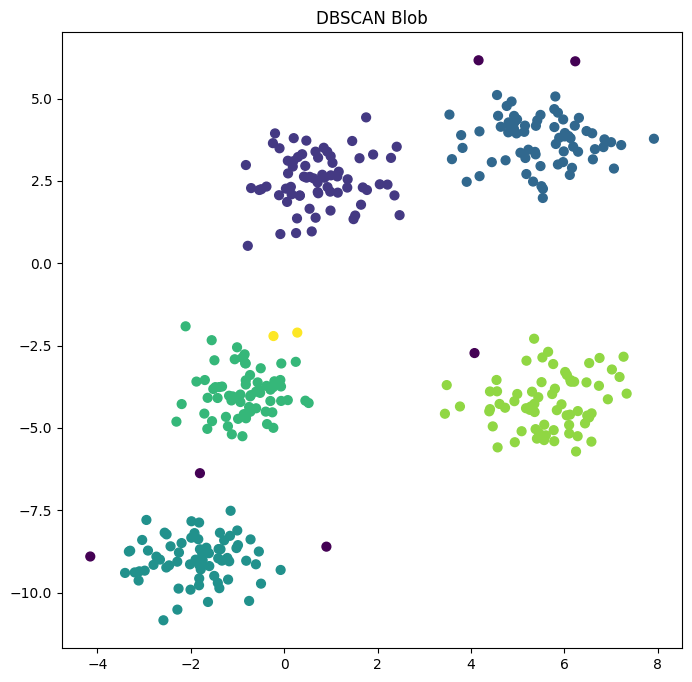

In [ ]:
# Plot with cluster
plot_dbscan(X)

## Unsing other datasets structure

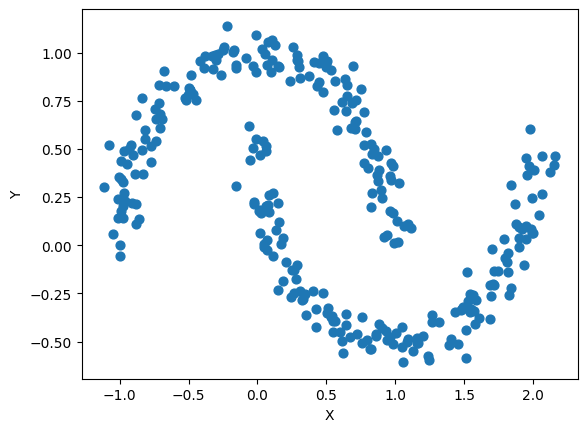

In [ ]:
from sklearn.datasets import make_moons
M, m = make_moons(n_samples=300, noise=0.07, random_state=40)

plt_data(M)

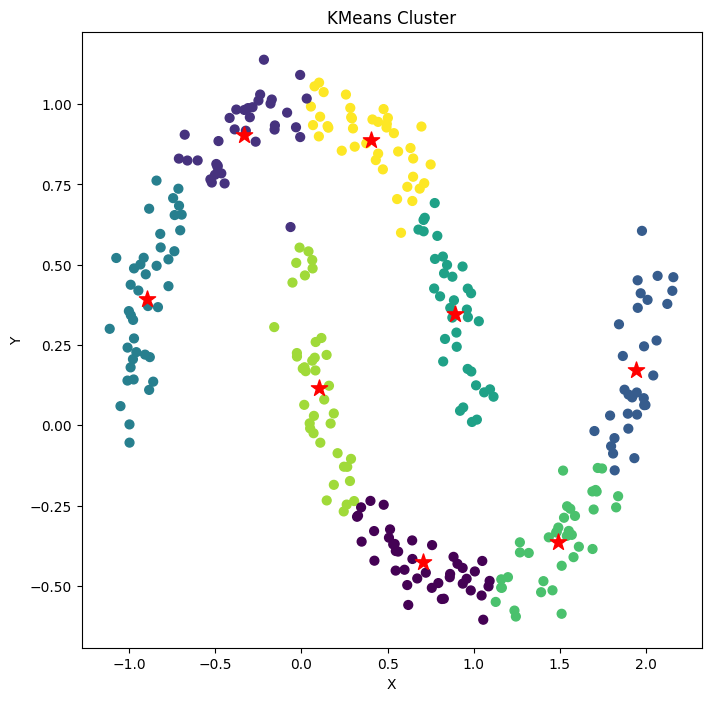

In [ ]:
#KMEANS
kmeans = KMeans(random_state=40)
kmeans.fit(M)

# Centroids
center = kmeans.cluster_centers_
labels = kmeans.labels_

plot_Kmeans(M)

Interia values:
1:302.50357509189877
2:122.29913544798268
3:81.10548080715223
4:52.81920943390931
5:40.77169615976075
6:34.94322399575719
7:22.555024908759833
8:17.02417475994062
9:13.726623440705804


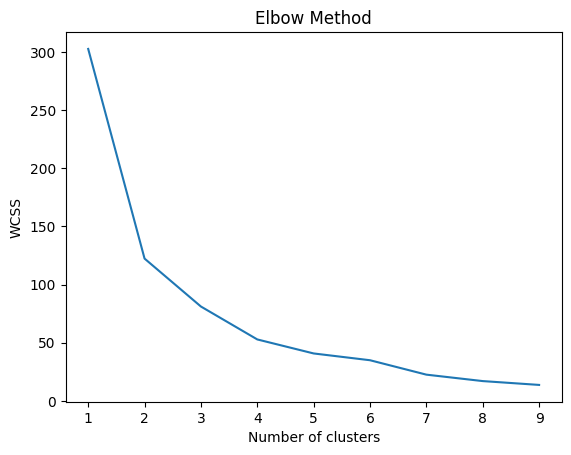

In [ ]:
elbow_method(M)

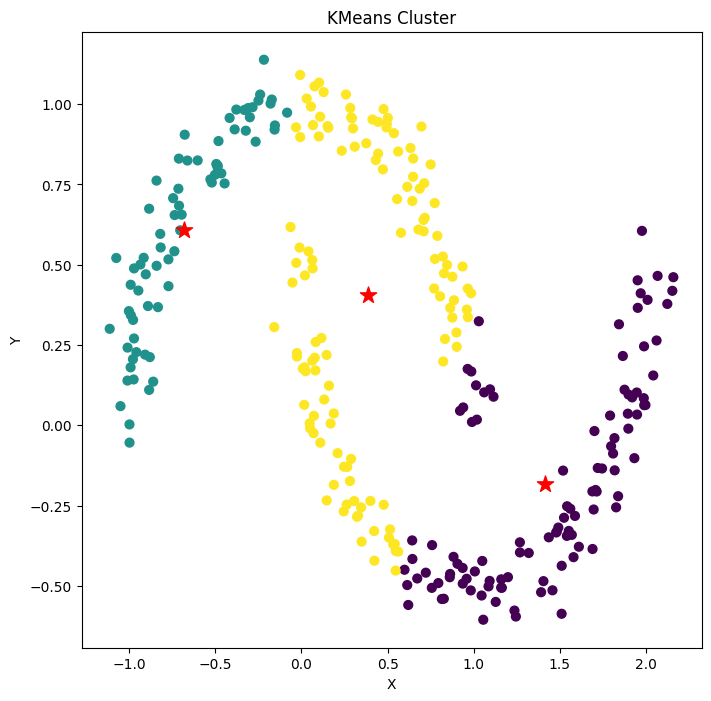

In [ ]:
kmeans = KMeans(n_clusters = 3, init='k-means++', random_state=40)
kmeans.fit(M)

# Centroids
center = kmeans.cluster_centers_
labels = kmeans.labels_

plot_Kmeans(M)

Estimated number of clusters: 3


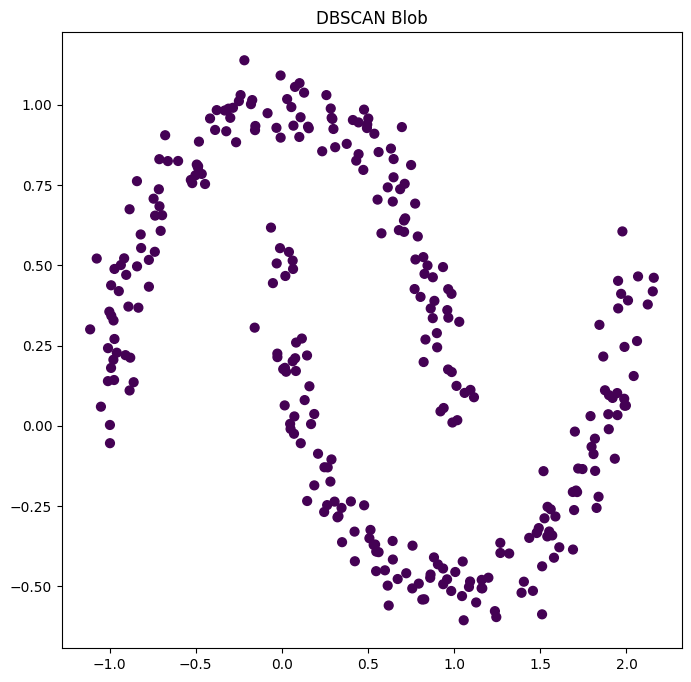

In [ ]:
#DBSCAN
db = DBSCAN()
db = DBSCAN(eps=0.30, min_samples=5).fit(M)
labels_db = db.labels_


# Number of clusters
n_clusters_ = len(set(labels))
print("Estimated number of clusters: %d" % n_clusters_)

plot_dbscan(M)

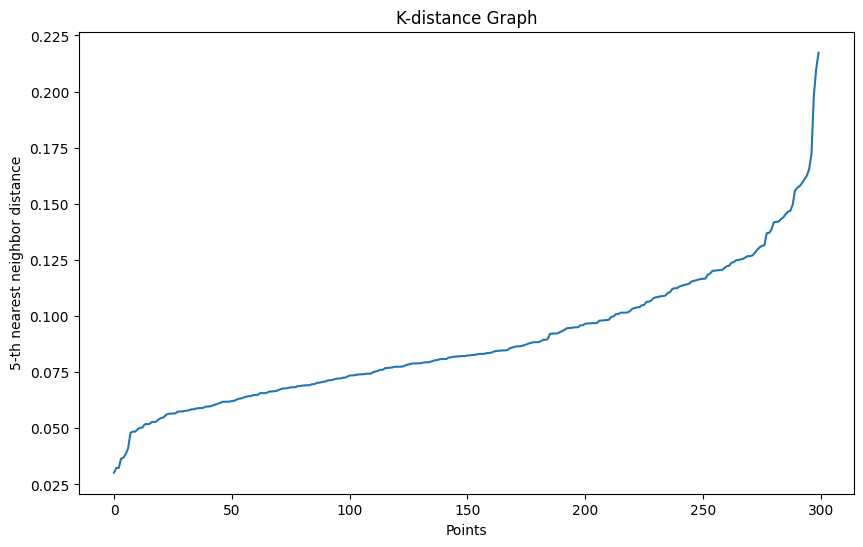

In [ ]:
k_distance(M)

Estimated number of clusters: 3


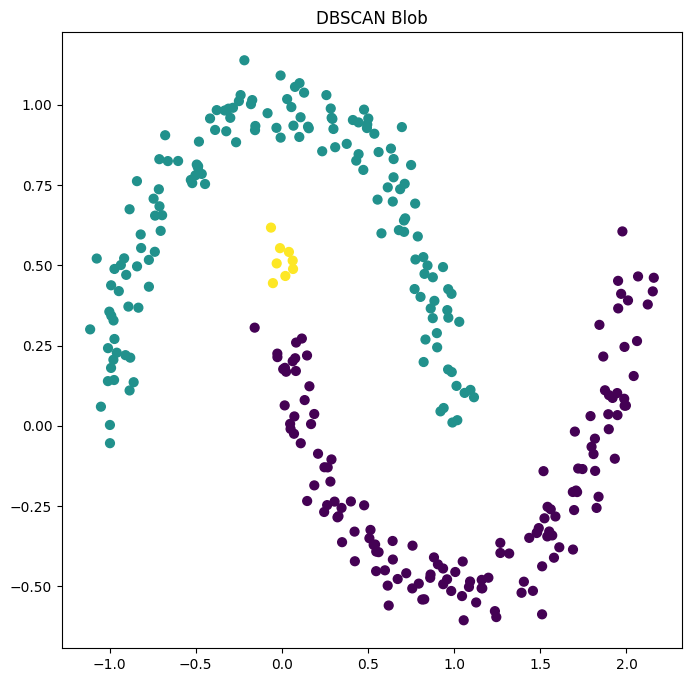

In [ ]:
#DBSCAN
db = DBSCAN()
db = DBSCAN(eps=0.175, min_samples=5).fit(M)
labels_db = db.labels_


# Number of clusters
n_clusters_ = len(set(labels))

print("Estimated number of clusters: %d" % n_clusters_)

plot_dbscan(M)

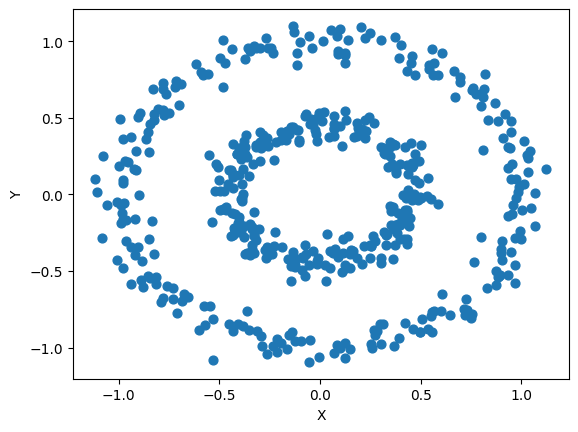

In [ ]:
from sklearn.datasets import make_circles

C, c = make_circles(n_samples=500, factor=0.45, noise=0.06, random_state=40)

plt_data(C)

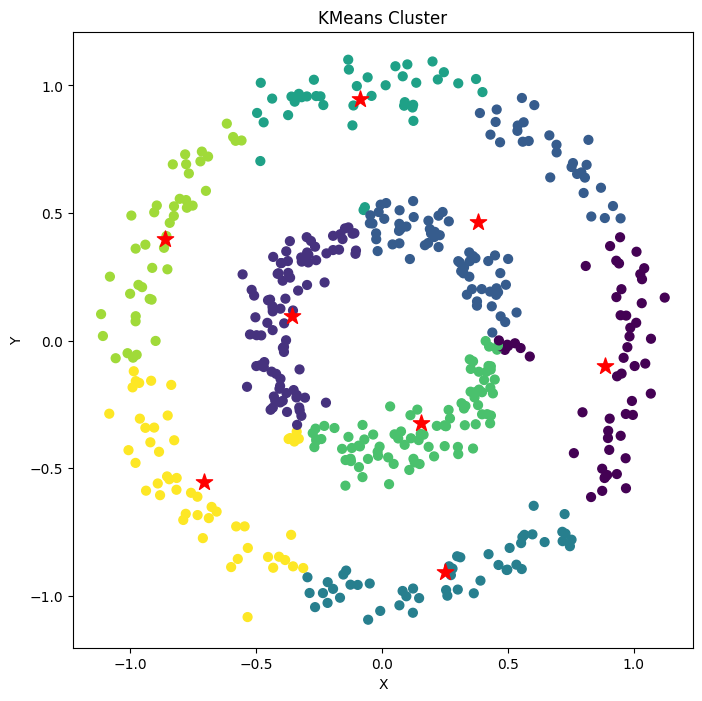

In [ ]:
#KMEANS
kmeans = KMeans(random_state=40)
kmeans.fit(C)

# Centroids
center = kmeans.cluster_centers_
labels = kmeans.labels_

# Plot with cluster
plot_Kmeans(C)

Interia values:
1:304.4998701421609
2:196.9775331790496
3:121.49529559357784
4:89.04064061565857
5:72.69713335246472
6:63.996321232584236
7:56.66223669769411
8:47.46892997819418
9:40.01626504744141


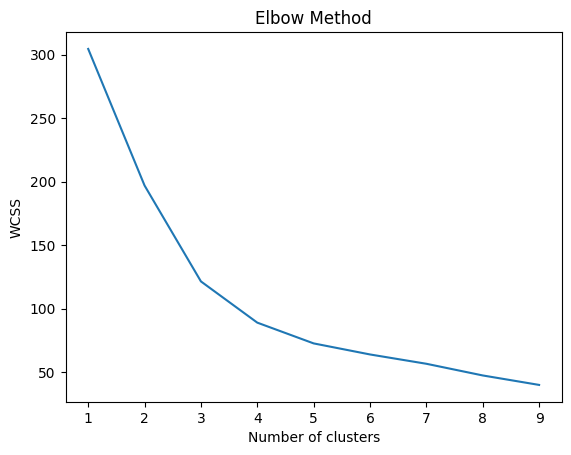

In [ ]:
elbow_method(C)

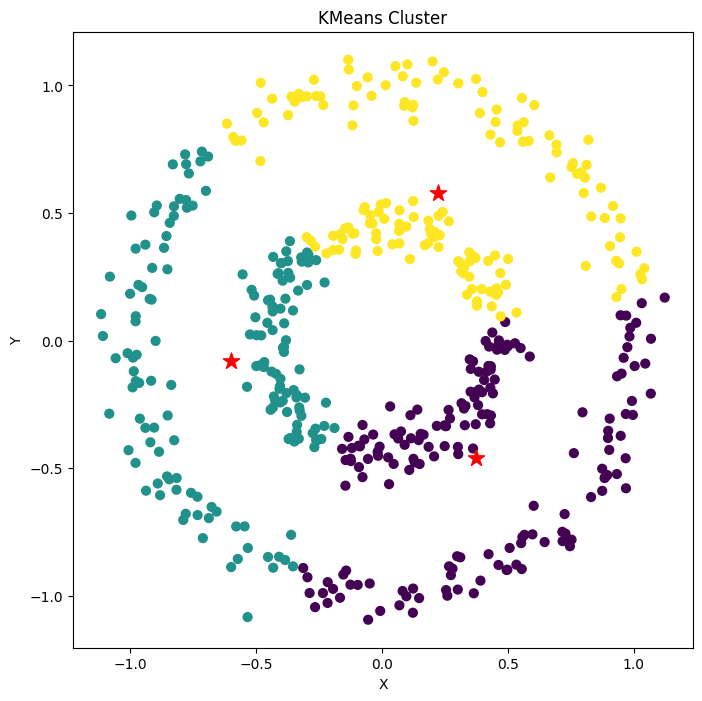

In [ ]:
kmeans = KMeans(n_clusters = 3, init='k-means++', random_state=40)
kmeans.fit(C)

# Centroids
center = kmeans.cluster_centers_
labels = kmeans.labels_

# Plot with cluster
plot_Kmeans(C)

Estimated number of clusters: 3


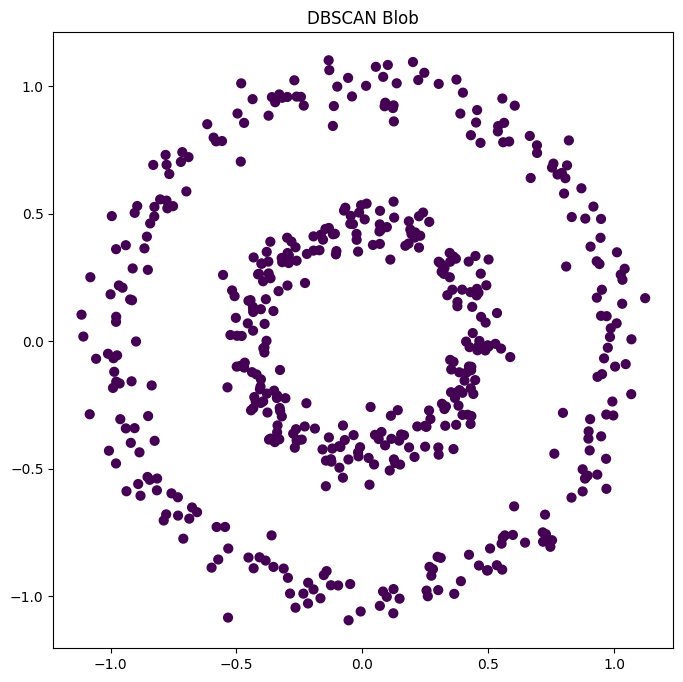

In [ ]:
#DBSCAN
db = DBSCAN()
db = DBSCAN(eps=0.30, min_samples=5).fit(C)
labels_db = db.labels_


# Number of clusters
n_clusters_ = len(set(labels))

print("Estimated number of clusters: %d" % n_clusters_)

plot_dbscan(C)

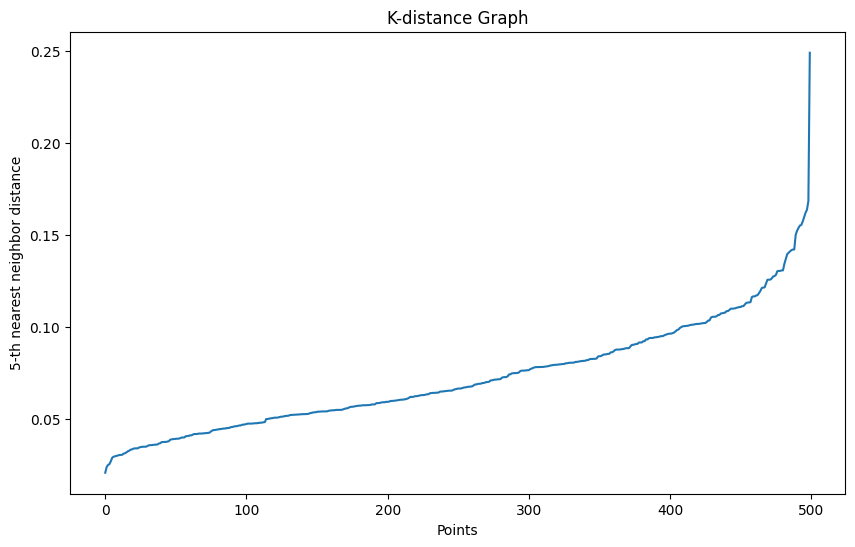

In [ ]:
k_distance(C)

Estimated number of clusters: 3


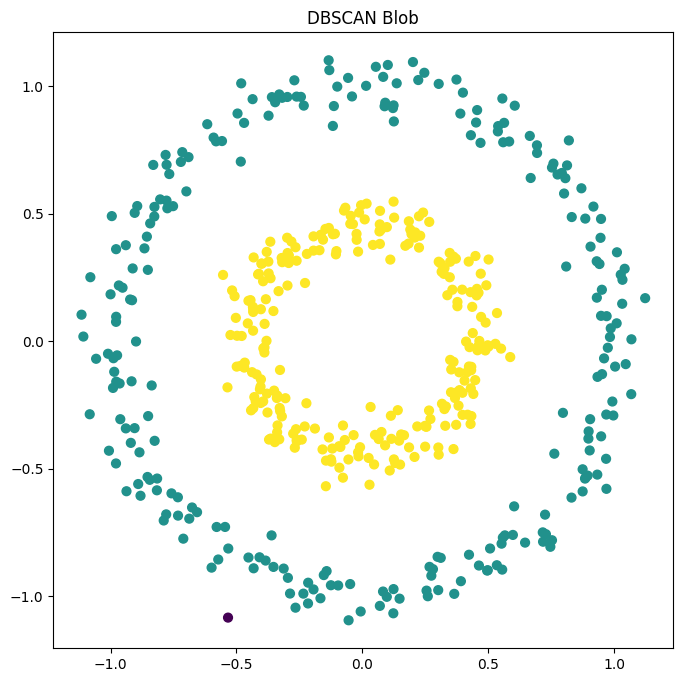

In [ ]:
#DBSCAN
db = DBSCAN()
db = DBSCAN(eps=0.150, min_samples=5).fit(C)
labels_db = db.labels_


# Number of clusters
n_clusters_ = len(set(labels))

print("Estimated number of clusters: %d" % n_clusters_)

plot_dbscan(C)

## Conclusions

In this activity we compared **K-Means** and **DBSCAN**, and we saw that they use two different ideas of what a “cluster” is.

- **K-Means** is **centroid-based**: it divides the data into groups by assigning each point to the closest centroid and it tries to minimize the within-cluster squared distances. It works well when clusters are compact and similar (like **Gaussian blobs**). But K-Means has problems with non-convex shapes (like moons or circles) and it can also be affected by outliers.

- **DBSCAN** is **density-based**: it creates clusters as connected dense areas and it marks points in low-density areas as noise. This is good for irregular shapes and when we want to detect outliers. However, DBSCAN can fail when clusters have very different densities, and it is very influenced by how we measure distances.

A key outcome is that both methods rely on a critical parameter, and the quality of the result depends heavily on choosing it well:

- For **K-Means**, the key parameter is the number of clusters **$k$**. The **elbow method** helps us choose $k$ by showing how the inertia (WCSS) decreases when $k$ increases. The “elbow” show the point where adding more clusters gives only small improvement, helping avoid underfitting and overfitting. K-Means is therefore sensitive to $k$: changing $k$ can completely change the partition.

- For **DBSCAN** , the key parameter is the radius $\varepsilon$ . The **k-distance graph** is important because it is connected directly to the density condition behind DBSCAN: points inside dense clusters have small k-distances, while border/noise points have bigger k-distances. The “knee” in the sorted k-distance plot suggests a good value for $\varepsilon$ to separate clusters from noise. DBSCAN is very sensitive to $\varepsilon$: if it is a bit smaller, clusters can split and many points become noise; if it is a bit bigger, different clusters can merge.

Overall, the main takeaway is that K-Means and DBSCAN succeed in different scenarios: K-Means is a good choice for simple and compact clusters, while DBSCAN is better for irregular shapes and noise handling. The elbow method and the k-distance graph are not just optional extras they are key tools for understanding which parameter to choose and for highlighting how sensitive each algorithm is to that choice.
